n patients: 136, n features: 957
(Strictly managing high feature-to-sample ratio: 957 vs 136)

            Model  Mean AUC (5-fold CV)    SD  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
    Random Forest                 0.729 0.112   0.760   0.648   0.886   0.565   0.784
Gradient Boosting                 0.690 0.098   0.781   0.523   0.790   0.653   0.705

14 robust features present in both models' cross-validated top 30:
 - Clonal TMB
 - DriverLoss 14q (RAD51B)
 - DriverLoss 22q (NF2)
 - Loss 22q
 - Loss ratio
 - Mutation NF2
 - ScarHRD LOH score
 - ScarHRD LST score
 - ScarHRD sum score
 - decoupleR:ARID1A
 - decoupleR:HCFC1
 - decoupleR:PAX5
 - decoupleR:SOX5
 - decoupleR:STOX1

Successfully updated and saved: table_rf_gb_performance.csv, mtap_discovery_FULL_ml_importance.csv, figure_roc_rf_gb.png


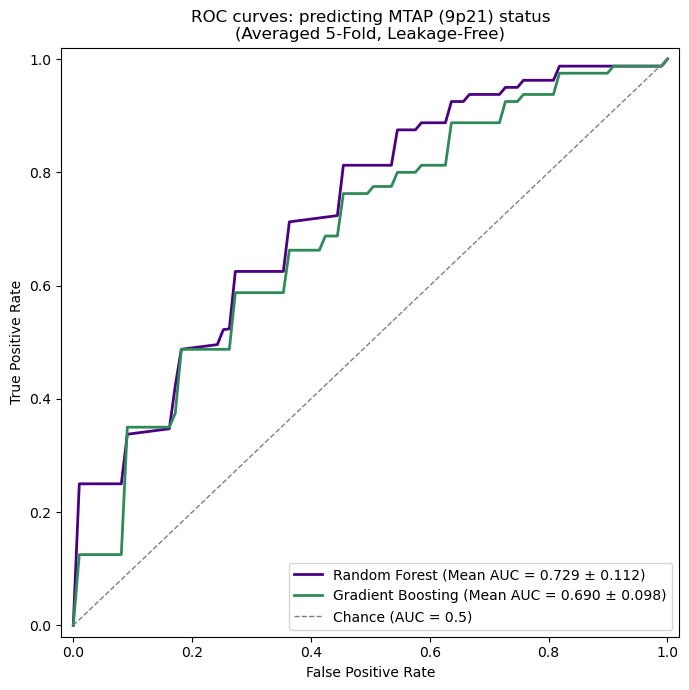

In [1]:
# Importing the necessary libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, auc

# Data preparation and Cleaning 
mtap_col = 'DriverLoss 9p21 (CDKN2A,MTAP,IFNA)'

df = pd.read_csv('/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv', low_memory=False)
df[mtap_col] = pd.to_numeric(df[mtap_col], errors='coerce')

# Build the structural genomic features list
genomic_cols = [c for c in df.columns if c.startswith(
    ('Mutation ', 'Loss ', 'Gain ', 'DriverLoss', 'DriverGain')) and c != mtap_col]
genomic_cols += ['Clonal TMB', 'Subclonal TMB', 'ScarHRD LOH score',
                 'ScarHRD TAI score', 'ScarHRD LST score', 'ScarHRD sum score']

# Dropping wide arm 9p/9q metrics to prevent target cheating/leakage
circular_cols = ['Loss 9p', 'Gain 9p', 'Loss 9q', 'Gain 9q']
genomic_cols = [c for c in genomic_cols if c not in circular_cols]

# Gather high-dimensional transcriptomic and cellular profiling features
rna_cols = [c for c in df.columns if c.startswith(
    ('ssGSEA:', 'RNA:', 'TRUST4:', 'Cibersort:', 'ConsensusTME:', 'xCell:', 'decoupleR:'))]

feature_cols = list(dict.fromkeys(genomic_cols + rna_cols))
track = df[[mtap_col] + feature_cols].dropna(subset=[mtap_col]).copy()

X_raw = track[feature_cols]
y = track[mtap_col].astype(int)

# Filter out features missing more than 50% data across patients
completeness = X_raw.notna().mean()
ml_features = completeness[completeness >= 0.5].index.tolist()
X = X_raw[ml_features]

print(f"n patients: {len(y)}, n features: {len(ml_features)}")
print(f"(Strictly managing high feature-to-sample ratio: {len(ml_features)} vs {len(y)})\n")

# Setup Validation and Models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced')
gb = GradientBoostingClassifier(n_estimators=300, random_state=42)

perf_rows = []
mean_fpr = np.linspace(0, 1, 100) # Standard grid for smooth ROC averaging

plt.figure(figsize=(7, 7))

# steelblue/darkorange is already spoken for elsewhere in the results section -
# that pair means "MTAP intact vs MTAP loss" everywhere else it shows up. this
# plot isn't comparing biological groups though, it's comparing two different
# model architectures on the same prediction task, so reusing the same two
# colours here would make it look like it's a MTAP status plot at a glance.
# going with indigo/seagreen instead so the two categories of figure (biology
# vs methods) are visually distinct from each other
colors = {'Random Forest': 'indigo', 'Gradient Boosting': 'seagreen'}

# Dictionaries to track stable importances across splits
rf_importances_cv = np.zeros(len(ml_features))
gb_importances_cv = np.zeros(len(ml_features))

# Cross Validation Loop to prevent data leakage
for name, model in [('Random Forest', rf), ('Gradient Boosting', gb)]:
    tprs = []
    fold_aucs = []
    fold_metrics = {}

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Leakage fix: Fit imputer on training fold only, transform validation fold
        imputer = SimpleImputer(strategy='mean')
        X_train_imp = imputer.fit_transform(X_train)
        X_val_imp = imputer.transform(X_val)

        # Train and Predict
        model.fit(X_train_imp, y_train)
        probs = model.predict_proba(X_val_imp)[:, 1]

        # Calculate isolated fold metrics
        fpr, tpr, _ = roc_curve(y_val, probs)
        fold_auc_val = auc(fpr, tpr)
        fold_aucs.append(fold_auc_val)
        fold_metrics[f'Fold {fold_idx}'] = round(fold_auc_val, 3)

        # Smooth curve interpolation
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

        # Interpretation fix: extracting important within fold to bypass global noise
        if name == 'Random Forest':
            rf_importances_cv += model.feature_importances_ / cv.n_splits
        elif name == 'Gradient Boosting':
            gb_importances_cv += model.feature_importances_ / cv.n_splits

    # Compute statistically precise cross-validation metrics
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    cv_mean_auc = np.mean(fold_aucs)
    cv_std_auc = np.std(fold_aucs)

    # Plot structurally correct averaged ROC curve
    plt.plot(mean_fpr, mean_tpr, color=colors[name], linewidth=2,
             label=f'{name} (Mean AUC = {cv_mean_auc:.3f} ± {cv_std_auc:.3f})')

    # Construct performance logging structure
    row = {
        'Model': name,
        'Mean AUC (5-fold CV)': round(cv_mean_auc, 3),
        'SD': round(cv_std_auc, 3)
    }
    row.update(fold_metrics)
    perf_rows.append(row)

# Exporting Perfomance Metrics
perf_df = pd.DataFrame(perf_rows)
print(perf_df.to_string(index=False))
perf_df.to_csv('table_rf_gb_performance.csv', index=False)

# Exporting the stable features
importance_df = pd.DataFrame({
    'RF_CV_Mean_Importance': rf_importances_cv,
    'GB_CV_Mean_Importance': gb_importances_cv
}, index=ml_features).sort_values('RF_CV_Mean_Importance', ascending=False)

importance_df.to_csv('mtap_discovery_FULL_ml_importance.csv')

# Highlight top biomarkers prioritized consistently by both architectures
top_rf = set(importance_df.sort_values('RF_CV_Mean_Importance', ascending=False).head(30).index)
top_gb = set(importance_df.sort_values('GB_CV_Mean_Importance', ascending=False).head(30).index)
agreed = top_rf & top_gb

print(f"\n{len(agreed)} robust features present in both models' cross-validated top 30:")
for f in sorted(agreed):
    print(' -', f)

# Exporting the ROC Diagram
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1, label='Chance (AUC = 0.5)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves: predicting MTAP (9p21) status\n(Averaged 5-Fold, Leakage-Free)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figure_roc_rf_gb.png', dpi=300, bbox_inches='tight')

print("\nSuccessfully updated and saved: table_rf_gb_performance.csv, mtap_discovery_FULL_ml_importance.csv, figure_roc_rf_gb.png")

/tmp/ipykernel_7250/4039861954.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['MTAP_status'] = df[mtap_col].map({0: 'Intact', 1: 'Lost'})


saved figure_mtap_binary_features.png


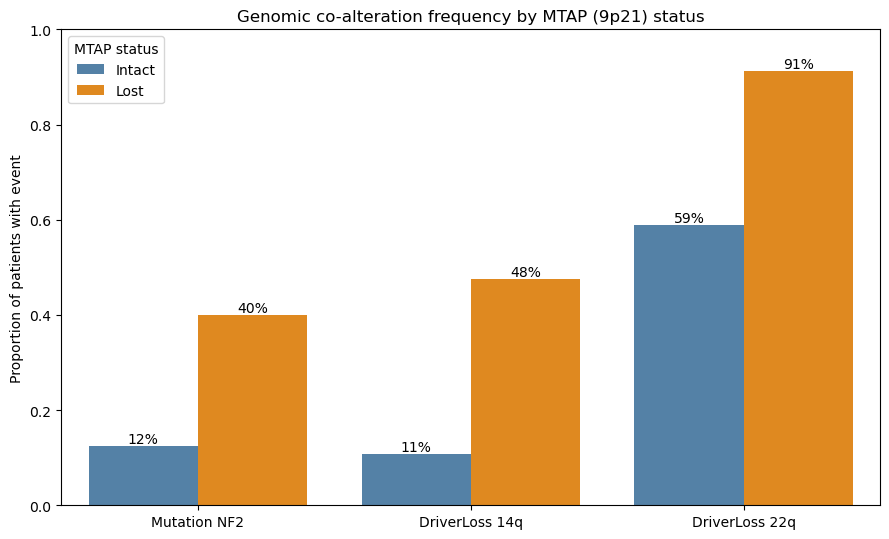

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compare the main genomic events between the MTAP-intact and MTAP-loss groups
# These were among the features picked up by both the Random Forest and Gradient Boosting models

df = pd.read_csv('/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv', low_memory=False)

# Use the 9p21 driver loss variable to separate patients by MTAP status
mtap_col = 'DriverLoss 9p21 (CDKN2A,MTAP,IFNA)'
df[mtap_col] = pd.to_numeric(df[mtap_col], errors='coerce')
df['MTAP_status'] = df[mtap_col].map({0: 'Intact', 1: 'Lost'})

# Genomic features to compare between the two groups
binary_feats = ['Mutation NF2', 'DriverLoss 14q (RAD51B)', 'DriverLoss 22q (NF2)']

# Calculate the proportion of patients with each event
prop_rows = []
for feat in binary_feats:
    df[feat] = pd.to_numeric(df[feat], errors='coerce')
    for status in ['Intact', 'Lost']:
        sub = df[df['MTAP_status'] == status][feat].dropna()
        clean_name = feat.replace(' (RAD51B)', '').replace(' (NF2)', '')
        prop_rows.append({'Feature': clean_name, 'MTAP status': status, 'Proportion': sub.mean()})

prop_df = pd.DataFrame(prop_rows)

# Plot the event frequencies for MTAP-intact and MTAP-loss patients
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(data=prop_df, x='Feature', y='Proportion', hue='MTAP status',
            palette={'Intact': 'steelblue', 'Lost': 'darkorange'}, ax=ax)
ax.set_ylabel('Proportion of patients with event')
ax.set_xlabel('')
ax.set_title('Genomic co-alteration frequency by MTAP (9p21) status')
ax.set_ylim(0, 1)

# Add the percentage above each bar to make the differences easier to read
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', labels=[f'{v.get_height()*100:.0f}%' for v in container])

# Save the finished figure
plt.tight_layout()
plt.savefig('figure_mtap_binary_features.png', dpi=300, bbox_inches='tight')
print('saved figure_mtap_binary_features.png')

/tmp/ipykernel_7250/599476383.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['MTAP_status'] = df[mtap_col].map({0: 'Intact', 1: 'Lost'})
/tmp/ipykernel_7250/599476383.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='MTAP_status', y=feat, order=['Intact', 'Lost'],
/tmp/ipykernel_7250/599476383.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='MTAP_status', y=feat, order=['Intact', 'Lost'],
/tmp/ipykernel_7250/599

saved figure_mtap_continuous_features.png


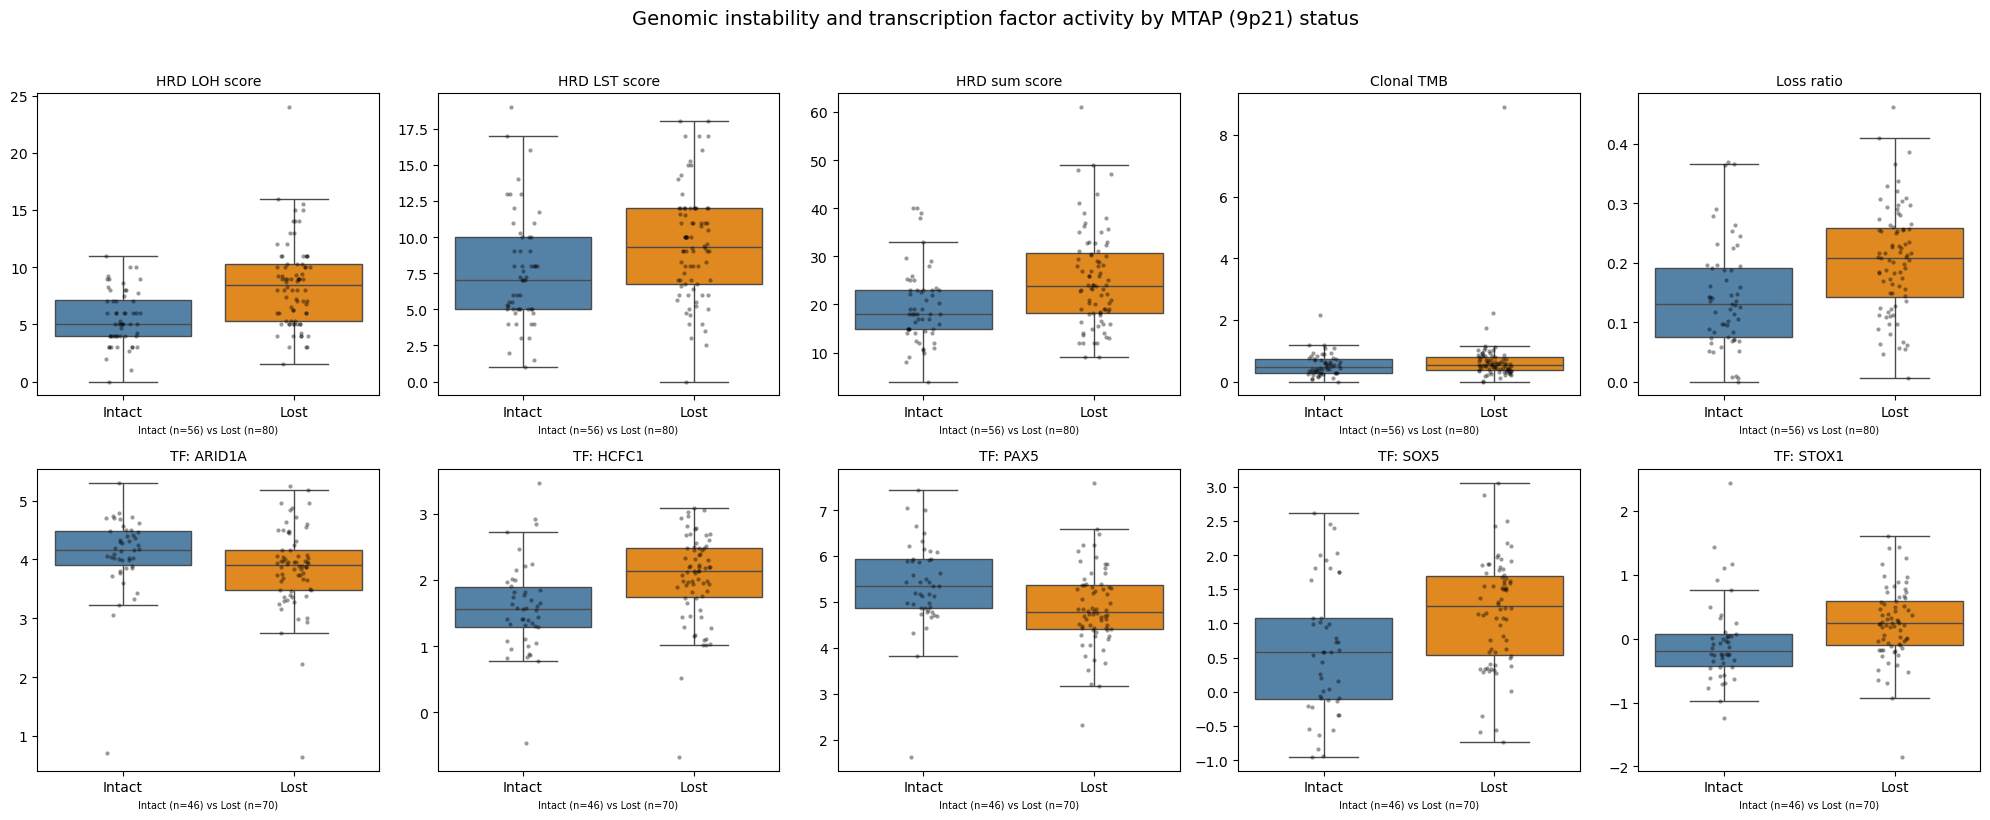

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Look at how the continuous features identified by both models differ by MTAP status
# This includes the genomic instability measures and transcription factor activity

df = pd.read_csv('/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv', low_memory=False)

# Split the patients into MTAP-intact and MTAP-loss groups
mtap_col = 'DriverLoss 9p21 (CDKN2A,MTAP,IFNA)'
df[mtap_col] = pd.to_numeric(df[mtap_col], errors='coerce')
df['MTAP_status'] = df[mtap_col].map({0: 'Intact', 1: 'Lost'})

# Continuous features that were shared between the two models
continuous_feats = ['ScarHRD LOH score', 'ScarHRD LST score', 'ScarHRD sum score', 'Clonal TMB',
                     'Loss ratio', 'decoupleR:ARID1A', 'decoupleR:HCFC1', 'decoupleR:PAX5',
                     'decoupleR:SOX5', 'decoupleR:STOX1']

# Put each feature into its own panel so they can be compared together
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(continuous_feats):
    ax = axes[i]
    df[feat] = pd.to_numeric(df[feat], errors='coerce')
    plot_df = df[[feat, 'MTAP_status']].dropna()

    # Boxplots show the overall distributions, with the individual patients overlaid
    sns.boxplot(data=plot_df, x='MTAP_status', y=feat, order=['Intact', 'Lost'],
                palette={'Intact': 'steelblue', 'Lost': 'darkorange'}, showfliers=False, ax=ax)
    sns.stripplot(data=plot_df, x='MTAP_status', y=feat, order=['Intact', 'Lost'],
                  color='black', alpha=0.4, size=3, ax=ax)

    # Add the number of patients available for each comparison
    n0 = (plot_df['MTAP_status'] == 'Intact').sum()
    n1 = (plot_df['MTAP_status'] == 'Lost').sum()
    label = feat.replace('decoupleR:', 'TF: ').replace('ScarHRD ', 'HRD ')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(f'Intact (n={n0}) vs Lost (n={n1})', fontsize=7)
    ax.set_ylabel('')

# Save the full panel as one figure
plt.suptitle('Genomic instability and transcription factor activity by MTAP (9p21) status', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figure_mtap_continuous_features.png', dpi=300, bbox_inches='tight')
print('saved figure_mtap_continuous_features.png')

/tmp/ipykernel_6094/1927605174.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['MTAP_status'] = df[mtap_col].map({0: 'Intact', 1: 'Lost'})
/tmp/ipykernel_6094/1927605174.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_6094/1927605174.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_6094/1927605174.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

saved figure_mtap_continuous_features_violin.png


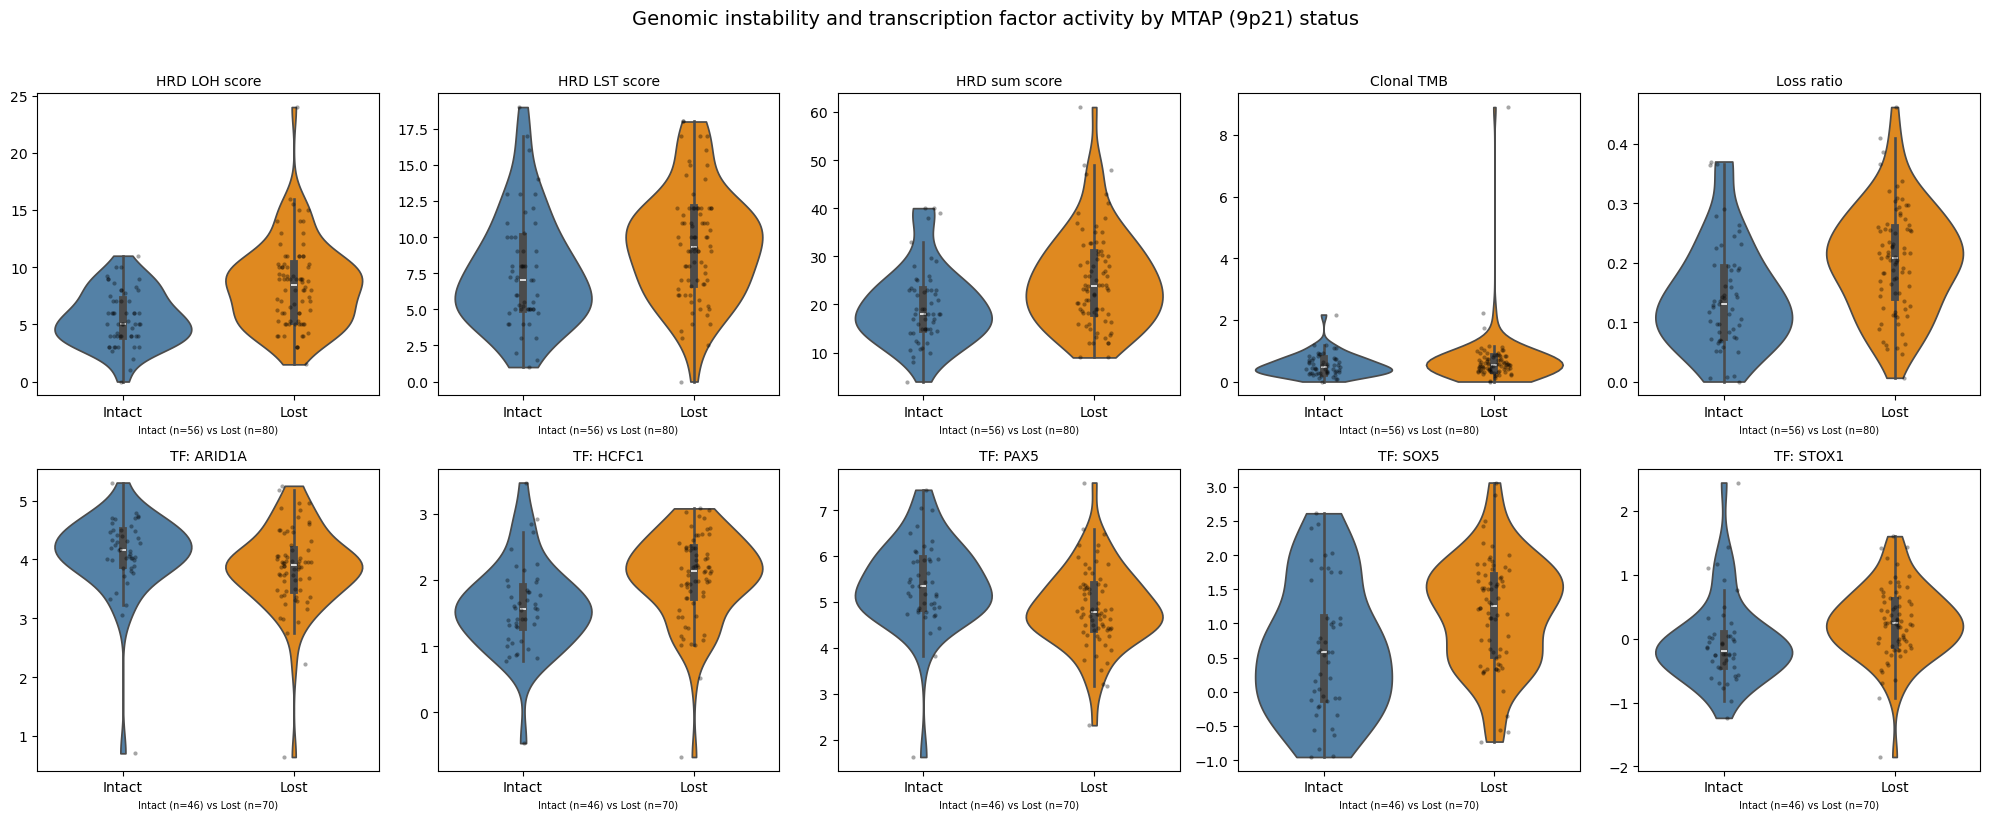

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Look at how the continuous features identified by both models differ by MTAP status
# This includes the genomic instability measures and transcription factor activity

df = pd.read_csv('/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv', low_memory=False)

# Split the patients into MTAP-intact and MTAP-loss groups
mtap_col = 'DriverLoss 9p21 (CDKN2A,MTAP,IFNA)'
df[mtap_col] = pd.to_numeric(df[mtap_col], errors='coerce')
df['MTAP_status'] = df[mtap_col].map({0: 'Intact', 1: 'Lost'})

# Continuous features that were shared between the two models
continuous_feats = [
    'ScarHRD LOH score',
    'ScarHRD LST score',
    'ScarHRD sum score',
    'Clonal TMB',
    'Loss ratio',
    'decoupleR:ARID1A',
    'decoupleR:HCFC1',
    'decoupleR:PAX5',
    'decoupleR:SOX5',
    'decoupleR:STOX1'
]

# Put each feature into its own panel so they can be compared together
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(continuous_feats):
    ax = axes[i]

    df[feat] = pd.to_numeric(df[feat], errors='coerce')
    plot_df = df[[feat, 'MTAP_status']].dropna()

    # Violin plots show the distribution of each feature in both MTAP groups
    sns.violinplot(
        data=plot_df,
        x='MTAP_status',
        y=feat,
        order=['Intact', 'Lost'],
        palette={'Intact': 'steelblue', 'Lost': 'darkorange'},
        inner='box',
        cut=0,
        ax=ax
    )

    # Show the individual patients on top of each distribution
    sns.stripplot(
        data=plot_df,
        x='MTAP_status',
        y=feat,
        order=['Intact', 'Lost'],
        color='black',
        alpha=0.35,
        size=3,
        jitter=True,
        ax=ax
    )

    # Add the number of patients available for each comparison
    n0 = (plot_df['MTAP_status'] == 'Intact').sum()
    n1 = (plot_df['MTAP_status'] == 'Lost').sum()

    label = (
        feat
        .replace('decoupleR:', 'TF: ')
        .replace('ScarHRD ', 'HRD ')
    )

    ax.set_title(label, fontsize=10)
    ax.set_xlabel(
        f'Intact (n={n0}) vs Lost (n={n1})',
        fontsize=7
    )
    ax.set_ylabel('')

# Save the full panel as one figure
plt.suptitle(
    'Genomic instability and transcription factor activity by MTAP (9p21) status',
    fontsize=14,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'figure_mtap_continuous_features_violin.png',
    dpi=300,
    bbox_inches='tight'
)

print('saved figure_mtap_continuous_features_violin.png')